# Deadlock in Python: Classic Example + Dining Philosophers

## Outline 

- a simple two-lock deadlock example
- a precise explanation of the four Coffman conditions
- a full **Dining Philosophers** simulation
- a demonstration of how deadlock can happen
- a corrected version that avoids deadlock
- visual summaries and discussion

---

## What you should expect to learn from this notebook

By the end of this notebook, you should be able to:

1. Define **deadlock**
2. Recognize the conditions under which deadlock occurs
3. Understand why the dining philosophers problem is a classic synchronization problem
4. Implement both a deadlocking and a deadlock-free strategy
5. Explain practical ways to avoid deadlock in real systems

In [1]:
import threading
import time
from dataclasses import dataclass, asdict
from collections import defaultdict
from statistics import mean
from typing import List, Dict, Any

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. What is deadlock?

A **deadlock** is a situation where two or more threads/processes are permanently blocked because each is waiting for a resource held by another.

### Intuition

Imagine:

- Thread A holds **Lock 1** and waits for **Lock 2**
- Thread B holds **Lock 2** and waits for **Lock 1**

Neither can proceed.

That is deadlock.

---

## 2. The four Coffman conditions

Deadlock can occur when all four of the following are true:

1. **Mutual exclusion**  
   At least one resource cannot be shared simultaneously.

2. **Hold and wait**  
   A thread holds one resource while waiting for another.

3. **No preemption**  
   Resources cannot be forcibly taken away; they must be released voluntarily.

4. **Circular wait**  
   A circular chain exists where each thread waits for a resource held by the next.

If we break at least one of these conditions, deadlock can be avoided.

## 3. Simple two-lock deadlock example

We begin with the smallest practical deadlock example.

There are two locks:

- `lock_a`
- `lock_b`

And two threads:

- Thread 1 acquires `lock_a` first, then tries `lock_b`
- Thread 2 acquires `lock_b` first, then tries `lock_a`

This creates the possibility of circular wait.

In [2]:
def simple_deadlock_demo(wait_timeout=1.0):
    """
    Demonstrate a deadlock pattern using two locks and two threads.

    We use acquire(timeout=...) instead of blocking forever so that
    the notebook remains safe to execute. If a second lock cannot be
    acquired before timeout, we treat that as a deadlock symptom.

    Returns
    -------
    dict
        Summary of what happened.
    """
    lock_a = threading.Lock()
    lock_b = threading.Lock()
    events = []

    def t1():
        events.append("T1: trying to acquire lock_a")
        with lock_a:
            events.append("T1: acquired lock_a")
            time.sleep(0.2)
            events.append("T1: trying to acquire lock_b")
            acquired = lock_b.acquire(timeout=wait_timeout)
            if acquired:
                try:
                    events.append("T1: acquired lock_b")
                finally:
                    lock_b.release()
            else:
                events.append("T1: timed out waiting for lock_b")

    def t2():
        events.append("T2: trying to acquire lock_b")
        with lock_b:
            events.append("T2: acquired lock_b")
            time.sleep(0.2)
            events.append("T2: trying to acquire lock_a")
            acquired = lock_a.acquire(timeout=wait_timeout)
            if acquired:
                try:
                    events.append("T2: acquired lock_a")
                finally:
                    lock_a.release()
            else:
                events.append("T2: timed out waiting for lock_a")

    a = threading.Thread(target=t1)
    b = threading.Thread(target=t2)

    start = time.perf_counter()
    a.start()
    b.start()
    a.join()
    b.join()
    elapsed = time.perf_counter() - start

    deadlock_symptom = any("timed out waiting" in e for e in events)

    return {
        "elapsed_s": elapsed,
        "deadlock_symptom_detected": deadlock_symptom,
        "events": events
    }

simple_result = simple_deadlock_demo()
simple_result

{'elapsed_s': 1.200799210000696,
 'deadlock_symptom_detected': True,
 'events': ['T1: trying to acquire lock_a',
  'T1: acquired lock_a',
  'T2: trying to acquire lock_b',
  'T2: acquired lock_b',
  'T1: trying to acquire lock_b',
  'T2: trying to acquire lock_a',
  'T1: timed out waiting for lock_b',
  'T2: acquired lock_a']}

### Why this is a deadlock pattern

This code reflects all four Coffman conditions:

- **Mutual exclusion**: locks are exclusive
- **Hold and wait**: each thread holds one lock and waits for another
- **No preemption**: a lock cannot be taken away
- **Circular wait**: T1 waits for T2's lock, and T2 waits for T1's lock

In the notebook, we use **timeouts** to avoid freezing the kernel forever.  
In real programs, a badly written version may simply hang.

## 4. Fixing the simple example

One common solution is **global lock ordering**.

If every thread acquires locks in the same order, circular wait is broken.

For example:

- always acquire `lock_a` before `lock_b`

In [3]:
def ordered_lock_demo():
    """
    Avoid deadlock by acquiring locks in the same global order.
    """
    lock_a = threading.Lock()
    lock_b = threading.Lock()
    events = []

    def worker(name):
        events.append(f"{name}: trying lock_a")
        with lock_a:
            events.append(f"{name}: acquired lock_a")
            time.sleep(0.1)
            events.append(f"{name}: trying lock_b")
            with lock_b:
                events.append(f"{name}: acquired lock_b")
                time.sleep(0.05)
            events.append(f"{name}: released lock_b")
        events.append(f"{name}: released lock_a")

    threads = [
        threading.Thread(target=worker, args=("T1",)),
        threading.Thread(target=worker, args=("T2",)),
    ]

    start = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    elapsed = time.perf_counter() - start

    return {"elapsed_s": elapsed, "events": events}

ordered_result = ordered_lock_demo()
ordered_result

{'elapsed_s': 0.3008086640002148,
 'events': ['T1: trying lock_a',
  'T1: acquired lock_a',
  'T2: trying lock_a',
  'T1: trying lock_b',
  'T1: acquired lock_b',
  'T1: released lock_b',
  'T1: released lock_a',
  'T2: acquired lock_a',
  'T2: trying lock_b',
  'T2: acquired lock_b',
  'T2: released lock_b',
  'T2: released lock_a']}

## 5. The Dining Philosophers problem

The **Dining Philosophers** problem is a classic synchronization problem.

### Story

- Five philosophers sit around a circular table
- A fork is placed between each pair of philosophers
- Each philosopher alternates between:
  - thinking
  - getting hungry
  - eating
- To eat, a philosopher needs **both adjacent forks**

### Why it matters

It models contention for limited shared resources.

The core challenge is:

> How can multiple agents share resources safely without deadlock or starvation?

This is highly relevant to:

- threads competing for locks
- database transactions competing for rows
- distributed workers competing for limited services
- networked processes sharing bounded resources

In [4]:
@dataclass
class PhilosopherRunSummary:
    strategy: str
    n_philosophers: int
    rounds_per_philosopher: int
    completed: bool
    total_meals: int
    avg_meals_per_philosopher: float
    min_meals_by_any_philosopher: int
    max_meals_by_any_philosopher: int
    elapsed_s: float

def philosopher_names(n):
    return [f"P{i}" for i in range(n)]

## 6. A deadlocking dining philosophers strategy

Here is the classic dangerous strategy:

Each philosopher does the following:

1. pick up the **left fork**
2. then try to pick up the **right fork**

If all philosophers pick up their left fork at the same time, then:

- everyone holds one fork
- everyone waits for the second fork
- nobody can continue

That is deadlock.

In [5]:
def run_dining_philosophers_deadlocking(
    n=5,
    rounds=3,
    think_time=0.05,
    eat_time=0.05,
    second_fork_timeout=0.4,
):
    """
    Deadlock-prone version of dining philosophers.

    To keep the notebook safe, philosophers use a timeout when waiting
    for the second fork. A timeout indicates a deadlock symptom or
    at least severe circular waiting.

    Returns
    -------
    summary : PhilosopherRunSummary
    events : list[str]
    meals : dict[str, int]
    """
    forks = [threading.Lock() for _ in range(n)]
    names = philosopher_names(n)
    meals = {name: 0 for name in names}
    events = []
    deadlock_symptom = threading.Event()

    def philosopher(i):
        left = forks[i]
        right = forks[(i + 1) % n]
        name = names[i]

        for r in range(rounds):
            events.append(f"{name}: thinking (round {r+1})")
            time.sleep(think_time)

            events.append(f"{name}: hungry, trying LEFT fork")
            left.acquire()
            events.append(f"{name}: acquired LEFT fork")

            # Small delay makes it easier to reproduce circular waiting
            time.sleep(0.03)

            events.append(f"{name}: trying RIGHT fork")
            acquired_right = right.acquire(timeout=second_fork_timeout)

            if not acquired_right:
                events.append(f"{name}: timeout waiting for RIGHT fork -> deadlock symptom")
                deadlock_symptom.set()
                left.release()
                events.append(f"{name}: released LEFT fork after timeout")
                return

            try:
                events.append(f"{name}: acquired RIGHT fork")
                events.append(f"{name}: eating")
                time.sleep(eat_time)
                meals[name] += 1
            finally:
                right.release()
                left.release()
                events.append(f"{name}: released both forks")

    threads = [threading.Thread(target=philosopher, args=(i,)) for i in range(n)]

    start = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    elapsed = time.perf_counter() - start

    total_meals = sum(meals.values())
    summary = PhilosopherRunSummary(
        strategy="Deadlock-prone: always left then right",
        n_philosophers=n,
        rounds_per_philosopher=rounds,
        completed=not deadlock_symptom.is_set(),
        total_meals=total_meals,
        avg_meals_per_philosopher=total_meals / n,
        min_meals_by_any_philosopher=min(meals.values()),
        max_meals_by_any_philosopher=max(meals.values()),
        elapsed_s=elapsed,
    )

    return summary, events, meals

deadlock_summary, deadlock_events, deadlock_meals = run_dining_philosophers_deadlocking()
pd.DataFrame([asdict(deadlock_summary)])

,strategy,n_philosophers,rounds_per_philosopher,completed,total_meals,avg_meals_per_philosopher,min_meals_by_any_philosopher,max_meals_by_any_philosopher,elapsed_s
0,Deadlock-prone: always left then right,5,3,False,3,0.6,0,3,0.791806


In [6]:
pd.DataFrame(
    {"philosopher": list(deadlock_meals.keys()), "meals_completed": list(deadlock_meals.values())}
)

,philosopher,meals_completed
0,P0,0
1,P1,0
2,P2,0
3,P3,0
4,P4,3


### Interpretation

In the deadlock-prone strategy, you will often observe at least one philosopher timing out while waiting for the second fork.

That timeout is a **deadlock symptom** in this controlled notebook implementation.

A fully blocking implementation without timeout might freeze permanently.

## 7. Deadlock-free strategy: break circular wait

A common solution is to enforce a resource ordering.

### Strategy used here

Each philosopher always acquires the **lower-indexed fork first**, then the higher-indexed fork.

This breaks circular wait because there is a single global order on resources.

In [7]:
def run_dining_philosophers_ordered(
    n=5,
    rounds=5,
    think_time=0.03,
    eat_time=0.04,
):
    """
    Deadlock-free dining philosophers using global resource ordering.
    """
    forks = [threading.Lock() for _ in range(n)]
    names = philosopher_names(n)
    meals = {name: 0 for name in names}
    events = []

    def philosopher(i):
        left_idx = i
        right_idx = (i + 1) % n
        first_idx, second_idx = sorted([left_idx, right_idx])

        first = forks[first_idx]
        second = forks[second_idx]
        name = names[i]

        for r in range(rounds):
            events.append(f"{name}: thinking (round {r+1})")
            time.sleep(think_time)

            events.append(f"{name}: trying fork {first_idx}")
            with first:
                events.append(f"{name}: acquired fork {first_idx}")
                time.sleep(0.01)

                events.append(f"{name}: trying fork {second_idx}")
                with second:
                    events.append(f"{name}: acquired fork {second_idx}")
                    events.append(f"{name}: eating")
                    time.sleep(eat_time)
                    meals[name] += 1

                events.append(f"{name}: released fork {second_idx}")
            events.append(f"{name}: released fork {first_idx}")

    threads = [threading.Thread(target=philosopher, args=(i,)) for i in range(n)]

    start = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    elapsed = time.perf_counter() - start

    total_meals = sum(meals.values())
    summary = PhilosopherRunSummary(
        strategy="Deadlock-free: global fork ordering",
        n_philosophers=n,
        rounds_per_philosopher=rounds,
        completed=True,
        total_meals=total_meals,
        avg_meals_per_philosopher=total_meals / n,
        min_meals_by_any_philosopher=min(meals.values()),
        max_meals_by_any_philosopher=max(meals.values()),
        elapsed_s=elapsed,
    )

    return summary, events, meals

ordered_summary, ordered_events, ordered_meals = run_dining_philosophers_ordered()
pd.DataFrame([asdict(ordered_summary)])

,strategy,n_philosophers,rounds_per_philosopher,completed,total_meals,avg_meals_per_philosopher,min_meals_by_any_philosopher,max_meals_by_any_philosopher,elapsed_s
0,Deadlock-free: global fork ordering,5,5,True,25,5.0,5,5,0.674734


In [8]:
pd.DataFrame(
    {"philosopher": list(ordered_meals.keys()), "meals_completed": list(ordered_meals.values())}
)

,philosopher,meals_completed
0,P0,5
1,P1,5
2,P2,5
3,P3,5
4,P4,5


## 8. Compare the two strategies

Now we place the two approaches side by side.

In [9]:
comparison = pd.DataFrame([
    asdict(deadlock_summary),
    asdict(ordered_summary),
])
comparison

,strategy,n_philosophers,rounds_per_philosopher,completed,total_meals,avg_meals_per_philosopher,min_meals_by_any_philosopher,max_meals_by_any_philosopher,elapsed_s
0,Deadlock-prone: always left then right,5,3,False,3,0.6,0,3,0.791806
1,Deadlock-free: global fork ordering,5,5,True,25,5.0,5,5,0.674734


In [10]:
comparison_plot = comparison[["strategy", "total_meals", "elapsed_s"]].copy()
comparison_plot

,strategy,total_meals,elapsed_s
0,Deadlock-prone: always left then right,3,0.791806
1,Deadlock-free: global fork ordering,25,0.674734


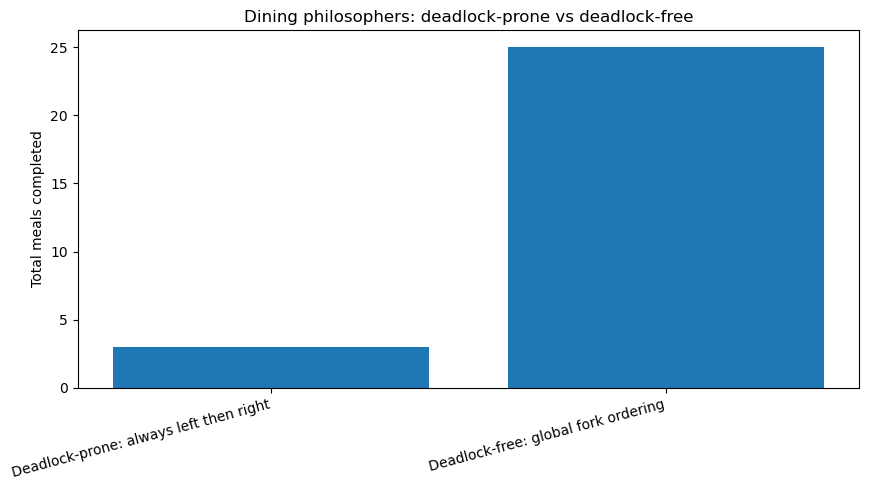

In [11]:
plt.figure(figsize=(9, 5))
plt.bar(comparison["strategy"], comparison["total_meals"])
plt.ylabel("Total meals completed")
plt.title("Dining philosophers: deadlock-prone vs deadlock-free")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### What this shows

- The **deadlock-prone** version may fail to complete all intended meals
- The **ordered** version completes safely
- The difference is not just correctness, but also reliability and predictability

In real systems, deadlock can cause:

- hanging services
- stuck database transactions
- blocked pipelines
- severe performance degradation

## 9. Optional alternative solution ideas

Besides lock ordering, common deadlock-avoidance approaches include:

### A. Allow at most `N - 1` philosophers to compete
For 5 philosophers, only 4 may try to pick up forks at the same time.

This guarantees at least one philosopher can complete and release resources.

### B. Use a waiter / arbitrator
A central controller grants permission to pick up forks.

This simplifies safety, but introduces coordination overhead and centralization.

### C. Try-lock + backoff
If a philosopher cannot obtain both forks, release the first fork, wait a random amount of time, and retry.

This reduces the chance of deadlock, though fairness must still be considered.

### D. One philosopher reverses order
For example, four philosophers pick left then right, but one picks right then left.

This breaks the circular wait cycle.

## 10. Deadlock vs starvation

These two terms are related but different.

### Deadlock
No participant can proceed.

### Starvation
Some participant could theoretically proceed, but one unlucky participant may wait indefinitely because others keep getting access first.

A system may be deadlock-free but still unfair.

That is why synchronization design should consider both:

- **safety**: avoid deadlock
- **liveness/fairness**: avoid starvation

## 11. Real-world relevance

The dining philosophers problem is not just theoretical.

It maps to many practical situations:

- threads acquiring multiple mutexes
- services acquiring several distributed locks
- transactions locking multiple database rows
- jobs competing for CPU, memory, GPUs, and I/O
- microservices waiting on each other in cycles

The lesson is general:

> When multiple actors need multiple shared resources, acquisition strategy matters.

Poor ordering can create deadlock.  
Careful ordering or coordination can prevent it.

## 12. Key takeaways

1. **Deadlock** happens when threads/processes wait forever in a cycle.
2. The four Coffman conditions explain when deadlock becomes possible.
3. The two-lock example is the simplest way to understand the problem.
4. The **Dining Philosophers** problem is a classic model of shared-resource contention.
5. A naive strategy can deadlock.
6. A **global resource ordering** strategy avoids deadlock by breaking circular wait.